<a href="https://colab.research.google.com/github/Patrick190508/whaleshark-mafia-island/blob/main/notebooks/MVP_Daily_Prediction_Ningaloo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Daily whale shark encounter prediction, Ningaloo Reef
**Minimum viable project: one site, the models of the Veritas Scholars course, one honest evaluation.**

Two versions of the question are tested on the same data:

- **Version 1 — "Will at least one whale shark be sighted today?"** (yes/no)
- **Version 2 — "Will today be a better-than-average day for its season?"** (above the season's mean number of sightings)

Data: OBIS human sightings matched to daily Copernicus SST, chlorophyll-a and salinity (`daily_ningaloo.csv`), peak season April–June, active seasons only (≥ 20 sightings). Days without a record count as 0 sightings (observation-effort limitation).

Models (all from the course): weekly baseline, logistic regression (Week 4), logistic regression with squared terms (Week 3), small neural network for classification (Week 6). Decision threshold tuned with the confusion matrix on the validation set.

Validation: training / validation / test sets split by season (time), never at random. The test set is used once, at the end of each version.

## 1. Data

### 1.1 Load the daily series and build the season table
One row per day of the season with that day's environmental values, day of season, week, and both targets.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/Patrick190508/whaleshark-mafia-island/main/data/daily_ningaloo.csv"
d = pd.read_csv(URL, parse_dates=["date"])

PEAK = [4, 5, 6]                                   # Ningaloo season: April–June
d = d[d["month"].isin(PEAK)].copy()
d["sday"] = d.groupby("year").cumcount() + 1       # day of season 1..91
d["week"] = (d["sday"] - 1) // 7 + 1

# active seasons only (>= 20 sightings), as in the EDA
tot = d.groupby("year")["sightings"].sum()
active = tot[tot >= 20].index
d = d[d["year"].isin(active)].dropna(subset=["sst", "chl", "sss"]).copy()

# squared terms for the polynomial model (Week 3)
d["sday2"] = d["sday"] ** 2
d["sst2"]  = d["sst"] ** 2

# target v1: at least one sighting that day
d["y1"] = (d["sightings"] > 0).astype(int)

# target v2: better-than-average day for its own season
avg = d.groupby("year")["sightings"].transform("mean")
d["y2"] = (d["sightings"] > avg).astype(int)

print("seasons:", sorted(d["year"].unique()))
print("rows:", len(d))
print("v1 — days with >= 1 sighting:", d["y1"].sum(), f"({d['y1'].mean():.0%})")
print("v2 — better-than-average days:", d["y2"].sum(), f"({d['y2'].mean():.0%})")

seasons: [np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009)]
rows: 1092
v1 — days with >= 1 sighting: 748 (68%)
v2 — better-than-average days: 404 (37%)


### 1.2 Train / validation / test split by season
Earliest seasons → training; two later seasons → validation (to tune); most recent seasons → test (used once).

In [2]:
TRAIN = list(range(1998, 2005))
VAL   = [2005, 2006]
TEST  = [2007, 2008, 2009]

train = d[d["year"].isin(TRAIN)]
val   = d[d["year"].isin(VAL)]
test  = d[d["year"].isin(TEST)]

for name, part in [("train", train), ("validation", val), ("test", test)]:
    print(f"{name:11s} seasons {part['year'].min()}–{part['year'].max()} | days {len(part):4d} | "
          f"v1 share {part['y1'].mean():.0%} | v2 share {part['y2'].mean():.0%}")

train       seasons 1998–2004 | days  637 | v1 share 55% | v2 share 33%
validation  seasons 2005–2006 | days  182 | v1 share 81% | v2 share 43%
test        seasons 2007–2009 | days  273 | v1 share 90% | v2 share 42%


### 1.3 Scoring function and feature matrices
Accuracy and confusion matrix. FP = empty trip (predicted good, was not); FN = missed good day.

In [3]:
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

def score(y_true, p, thr=0.5, label=""):
    pred = (np.asarray(p) >= thr).astype(int)
    acc = accuracy_score(y_true, pred)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    print(f"{label:26s} acc {acc:.2f} | TP {tp:3d} FP {fp:3d} FN {fn:3d} TN {tn:3d}")
    return acc

FEATS  = ["sday", "sst", "chl", "sss"]                       # linear
FEATS2 = ["sday", "sday2", "sst", "sst2", "chl", "sss"]      # with squared terms

sc1 = StandardScaler().fit(train[FEATS])
Xtr1, Xva1, Xte1 = (sc1.transform(p[FEATS]) for p in (train, val, test))
sc2 = StandardScaler().fit(train[FEATS2])
Xtr2, Xva2, Xte2 = (sc2.transform(p[FEATS2]) for p in (train, val, test))

def weekly_baseline(y):
    """share of positive days per week of season, from the training seasons"""
    return train.groupby("week")[y].mean().rename("p_week")

def coef_plot(model, feats, title):
    coef = pd.Series(model.coef_[0], index=feats).sort_values()
    print(coef.round(2))
    coef.plot(kind="barh", color="steelblue", figsize=(6, 3))
    plt.axvline(0, color="grey"); plt.title(title); plt.show()

## 2. Version 1 — "Will at least one whale shark be sighted today?"

### 2.1 Weekly baseline

week
1     0.45
2     0.61
3     0.69
4     0.69
5     0.67
6     0.59
7     0.59
8     0.61
9     0.67
10    0.57
11    0.41
12    0.29
13    0.35
Name: p_week, dtype: float64


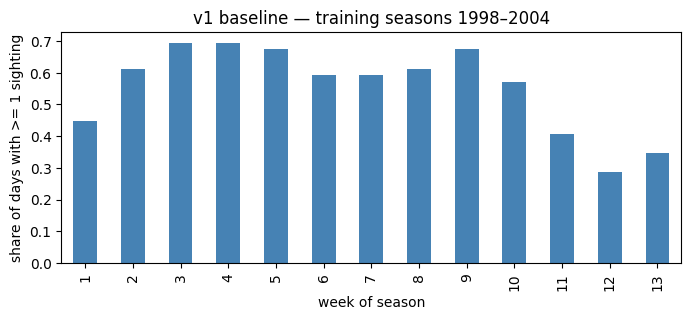

In [4]:
wk1 = weekly_baseline("y1")
print(wk1.round(2))
wk1.plot(kind="bar", color="steelblue", figsize=(8, 3))
plt.ylabel("share of days with >= 1 sighting"); plt.xlabel("week of season")
plt.title("v1 baseline — training seasons 1998–2004"); plt.show()

p_val_base1  = val["week"].map(wk1)
p_test_base1 = test["week"].map(wk1)

### 2.2 Logistic regression, with and without `year`

with year:
sss    -0.09
chl     0.15
sday    0.32
sst     0.82
year    1.35
dtype: float64


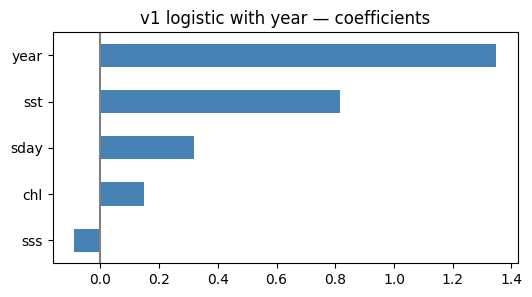

logistic + year (val)      acc 0.81 | TP 148 FP  34 FN   0 TN   0

without year:
sday   -0.81
sst    -0.38
sss     0.18
chl     0.40
dtype: float64


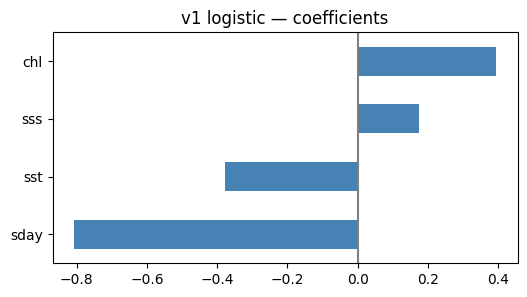

In [5]:
y1_tr, y1_va, y1_te = train["y1"], val["y1"], test["y1"]

# with year (to show what happens)
FY = FEATS + ["year"]
scy = StandardScaler().fit(train[FY])
logit_y = LogisticRegression(max_iter=1000).fit(scy.transform(train[FY]), y1_tr)
print("with year:"); coef_plot(logit_y, FY, "v1 logistic with year — coefficients")
score(y1_va, logit_y.predict_proba(scy.transform(val[FY]))[:, 1], 0.5, "logistic + year (val)")

# without year
logit1 = LogisticRegression(max_iter=1000).fit(Xtr1, y1_tr)
p_val_l1 = logit1.predict_proba(Xva1)[:, 1]
print("\nwithout year:"); coef_plot(logit1, FEATS, "v1 logistic — coefficients")

*Reading:* With `year` in the inputs it is the strongest coefficient by far: the share of days with a sighting rises from 55% (1998) to 90% (2009) because the photo-ID catalogue grows, and the model extrapolates that trend into the validation seasons, predicting "yes" on every day. `year` is effort, not ecology, and is dropped.

### 2.3 Logistic regression with squared terms

sday2   -1.74
sst2    -0.68
sst      0.07
sss      0.16
chl      0.40
sday     0.68
dtype: float64


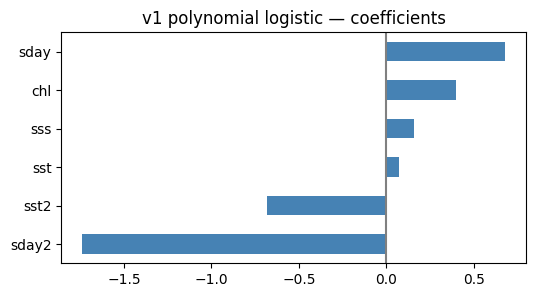

In [6]:
logit1p = LogisticRegression(max_iter=1000).fit(Xtr2, y1_tr)
p_val_l1p = logit1p.predict_proba(Xva2)[:, 1]
coef_plot(logit1p, FEATS2, "v1 polynomial logistic — coefficients")

### 2.4 Threshold tuning on the validation set — all models at equal thresholds

In [7]:
for thr in [0.3, 0.4, 0.5, 0.6]:
    score(y1_va, p_val_base1, thr, f"baseline thr {thr}")
    score(y1_va, p_val_l1,    thr, f"logistic thr {thr}")
    score(y1_va, p_val_l1p,   thr, f"poly-logistic thr {thr}")
    print()
score(y1_va, np.ones(len(val)), label="always 'yes' (val)")

baseline thr 0.3           acc 0.77 | TP 137 FP  31 FN  11 TN   3
logistic thr 0.3           acc 0.81 | TP 148 FP  34 FN   0 TN   0
poly-logistic thr 0.3      acc 0.83 | TP 146 FP  29 FN   2 TN   5

baseline thr 0.4           acc 0.76 | TP 129 FP  25 FN  19 TN   9
logistic thr 0.4           acc 0.75 | TP 137 FP  34 FN  11 TN   0
poly-logistic thr 0.4      acc 0.75 | TP 127 FP  25 FN  21 TN   9

baseline thr 0.5           acc 0.68 | TP 108 FP  18 FN  40 TN  16
logistic thr 0.5           acc 0.53 | TP  84 FP  21 FN  64 TN  13
poly-logistic thr 0.5      acc 0.59 | TP  97 FP  24 FN  51 TN  10

baseline thr 0.6           acc 0.46 | TP  67 FP  17 FN  81 TN  17
logistic thr 0.6           acc 0.43 | TP  60 FP  15 FN  88 TN  19
poly-logistic thr 0.6      acc 0.48 | TP  72 FP  19 FN  76 TN  15

always 'yes' (val)         acc 0.81 | TP 148 FP  34 FN   0 TN   0


0.8131868131868132

*Reading:* The linear model is worse than the weekly baseline at every threshold: a straight line cannot describe a season that rises, peaks and falls. With squared terms (`sday²`) the model reproduces the bell shape and matches the baseline, but never beats it consistently. Both are below "always yes" (0.81), because 81% of validation days have a sighting. Threshold 0.3 is chosen for the test.

### 2.5 Test (used once)

In [8]:
p_test_l1p = logit1p.predict_proba(Xte2)[:, 1]
score(y1_te, p_test_base1, 0.3, "baseline thr 0.3 (test)")
score(y1_te, p_test_l1p,   0.3, "poly-logistic thr 0.3 (test)")
score(y1_te, np.ones(len(test)), label="always 'yes' (test)")

baseline thr 0.3 (test)    acc 0.84 | TP 228 FP  24 FN  19 TN   2
poly-logistic thr 0.3 (test) acc 0.86 | TP 234 FP  26 FN  13 TN   0
always 'yes' (test)        acc 0.90 | TP 247 FP  26 FN   0 TN   0


0.9047619047619048

*Reading:* Baseline 0.84, polynomial logistic 0.86, "always yes" 0.90. The model never finds an empty day (TN = 0): it is a slightly worse version of "always yes".

**Conclusion of version 1.** In the peak season 80–90% of days have a sighting, so the best answer to "will a shark be seen?" is "yes, go out" — which is what operators already do. The question has no information left in it. It has to be changed.

## 3. Version 2 — "Will today be a better-than-average day for its season?"

Target: `y2` = 1 if the day's sightings are above the **mean of its own season**, 0 otherwise. Every season is compared with itself, so the growth of the catalogue no longer matters and the share of positive days is stable (about 35–45%). The trivial reference is now "always no" (the majority class).

### 3.1 Weekly baseline

week
1     0.16
2     0.29
3     0.41
4     0.47
5     0.43
6     0.37
7     0.45
8     0.39
9     0.41
10    0.35
11    0.18
12    0.20
13    0.18
Name: p_week, dtype: float64


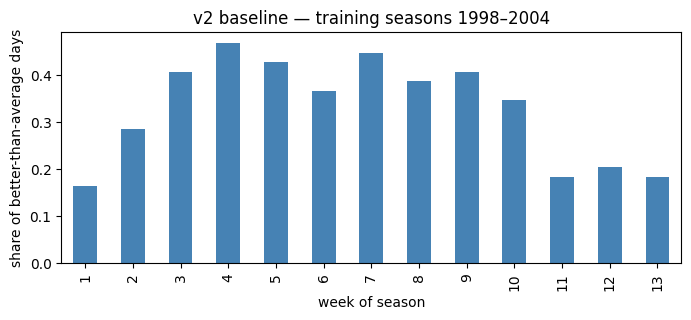

In [9]:
y2_tr, y2_va, y2_te = train["y2"], val["y2"], test["y2"]

wk2 = weekly_baseline("y2")
print(wk2.round(2))
wk2.plot(kind="bar", color="steelblue", figsize=(8, 3))
plt.ylabel("share of better-than-average days"); plt.xlabel("week of season")
plt.title("v2 baseline — training seasons 1998–2004"); plt.show()

p_val_base2  = val["week"].map(wk2)
p_test_base2 = test["week"].map(wk2)

### 3.2 Logistic regression (linear) and with squared terms

linear:
sday   -0.07
sss     0.06
chl     0.13
sst     0.14
dtype: float64


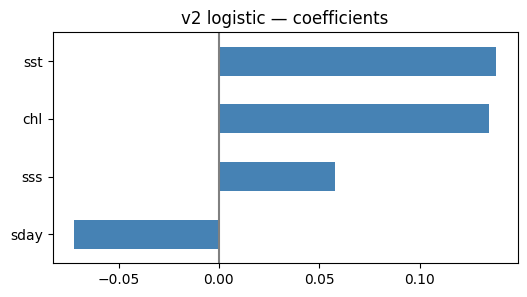


with squared terms:
sday2   -1.51
sst2    -0.10
sss      0.05
sst      0.08
chl      0.17
sday     1.22
dtype: float64


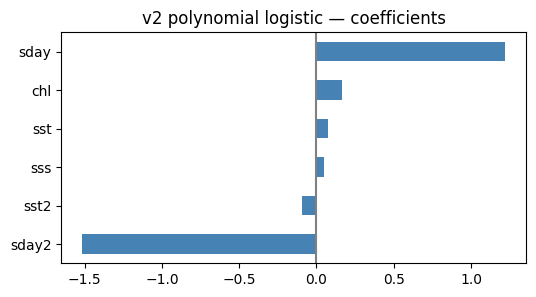

In [10]:
logit2 = LogisticRegression(max_iter=1000).fit(Xtr1, y2_tr)
p_val_l2 = logit2.predict_proba(Xva1)[:, 1]
print("linear:"); coef_plot(logit2, FEATS, "v2 logistic — coefficients")

logit2p = LogisticRegression(max_iter=1000).fit(Xtr2, y2_tr)
p_val_l2p = logit2p.predict_proba(Xva2)[:, 1]
print("\nwith squared terms:"); coef_plot(logit2p, FEATS2, "v2 polynomial logistic — coefficients")

### 3.3 Small neural network for classification (Week 6)
One hidden layer; manual search over its width (4, 8, 16 units). Same inputs as the polynomial model. The validation set picks the width.

In [11]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(0); np.random.seed(0)

def make_nn(units):
    m = keras.Sequential([
        keras.layers.Input(shape=(Xtr2.shape[1],)),
        keras.layers.Dense(units, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")])
    m.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return m

nn_models, nn_val = {}, {}
for units in [4, 8, 16]:
    m = make_nn(units)
    h = m.fit(Xtr2, y2_tr, epochs=100, batch_size=32, verbose=0, validation_data=(Xva2, y2_va))
    nn_models[units] = m
    nn_val[units] = m.predict(Xva2, verbose=0).ravel()
    print(f"{units:2d} units | train acc {h.history['accuracy'][-1]:.2f} | val acc {h.history['val_accuracy'][-1]:.2f}")

 4 units | train acc 0.66 | val acc 0.57
 8 units | train acc 0.67 | val acc 0.58


16 units | train acc 0.67 | val acc 0.59


### 3.4 Threshold tuning on the validation set — all models at equal thresholds

In [12]:
for thr in [0.3, 0.4, 0.5]:
    score(y2_va, p_val_base2, thr, f"baseline thr {thr}")
    score(y2_va, p_val_l2,    thr, f"logistic thr {thr}")
    score(y2_va, p_val_l2p,   thr, f"poly-logistic thr {thr}")
    for units in [4, 8, 16]:
        score(y2_va, nn_val[units], thr, f"nn {units:2d} units thr {thr}")
    print()
score(y2_va, np.zeros(len(val)), label="always 'no' (val)")

baseline thr 0.3           acc 0.58 | TP  57 FP  55 FN  22 TN  48
logistic thr 0.3           acc 0.51 | TP  61 FP  72 FN  18 TN  31
poly-logistic thr 0.3      acc 0.54 | TP  63 FP  68 FN  16 TN  35
nn  4 units thr 0.3        acc 0.53 | TP  59 FP  66 FN  20 TN  37
nn  8 units thr 0.3        acc 0.53 | TP  60 FP  66 FN  19 TN  37
nn 16 units thr 0.3        acc 0.61 | TP  47 FP  39 FN  32 TN  64

baseline thr 0.4           acc 0.55 | TP  34 FP  36 FN  45 TN  67
logistic thr 0.4           acc 0.59 | TP  13 FP   8 FN  66 TN  95
poly-logistic thr 0.4      acc 0.61 | TP  24 FP  16 FN  55 TN  87
nn  4 units thr 0.4        acc 0.59 | TP   6 FP   2 FN  73 TN 101
nn  8 units thr 0.4        acc 0.61 | TP  34 FP  26 FN  45 TN  77
nn 16 units thr 0.4        acc 0.62 | TP  23 FP  14 FN  56 TN  89

baseline thr 0.5           acc 0.57 | TP   0 FP   0 FN  79 TN 103
logistic thr 0.5           acc 0.56 | TP   0 FP   1 FN  79 TN 102
poly-logistic thr 0.5      acc 0.60 | TP   7 FP   0 FN  72 TN 103
nn  4 un

0.5659340659340659

*Reading:* Polynomial logistic 0.61, neural network 0.61, "always no" 0.58, weekly baseline 0.52. Both models are three points above the trivial answer. The network flags more days as good (80 vs 56) and is right on 55% of them, the logistic on 57%; the base rate is 42%. A small real signal, the same for both models, and it comes from the shape of the season, not from the environmental variables.

### 3.5 Test (used once)
Best model and threshold chosen on the validation set above — set them here before running.

In [13]:
THR      = 0.4          # chosen on validation
NN_UNITS = 16           # chosen on validation

p_test_l2p = logit2p.predict_proba(Xte2)[:, 1]
p_test_nn  = nn_models[NN_UNITS].predict(Xte2, verbose=0).ravel()

score(y2_te, p_test_base2, THR, f"baseline thr {THR} (test)")
score(y2_te, p_test_l2p,   THR, f"poly-logistic thr {THR} (test)")
score(y2_te, p_test_nn,    THR, f"nn {NN_UNITS} units thr {THR} (test)")
score(y2_te, np.zeros(len(test)), label="always 'no' (test)")

baseline thr 0.4 (test)    acc 0.52 | TP  45 FP  60 FN  70 TN  98
poly-logistic thr 0.4 (test) acc 0.61 | TP  32 FP  24 FN  83 TN 134
nn 16 units thr 0.4 (test) acc 0.61 | TP  44 FP  36 FN  71 TN 122
always 'no' (test)         acc 0.58 | TP   0 FP   0 FN 115 TN 158


0.5787545787545788

*Reading:*

## 4. Conclusions

**Version 1 — "at least one sighting?"** In the peak season 80–90% of days have a sighting, so every model converged on "always yes". Not a model failure: the question has no information left in it, and operators already go out every day in season.

**Version 2 — "better-than-average day?"** A fair question (about 37% of days). The environmental variables do not separate good days from normal days: the linear model equals "always no"; with squared terms the model gains a few points, and the gain comes from day of season (the bell shape), not from SST, chlorophyll or salinity, whose coefficients are close to zero.

The neural network (one hidden layer, 16 units) does no better than the polynomial logistic: 0.61 on test for both, with training accuracy of only 0.67 — the inputs do not contain more information for a more flexible model to find.

**What this means.** Slow satellite variables describe *when* the season is; they do not say *which day* inside it will be good. This is the EDA result confirmed by a predictive test, and it agrees with the daily-scale studies with effort data (Rohner 2013, Swai 2024): inside the season, only fast-changing variables (sea state, weather) add anything.

**Next steps**
1. Wind speed as a fast-changing input (daily series per site).
2. Philippines and Tofo with the same notebook; cross-site test (train on one site, test on another).
3. Effort: use the Cagua 2015 search-hours data at Mafia to check how much of "no sighting" is "no boat".